# Setup and imports

In [1]:
!pip install torch-geometric -q
#!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.1.0+cpu.html -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.9 MB/s eta 0:00:00


In [2]:
# ============================================================================
# SETUP: Instalar dependencias
# ============================================================================



import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# # Configurar dispositivo
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Device: {device}")

# # Verificar GPU
# if torch.cuda.is_available():
#     print(f"GPU: {torch.cuda.get_device_name(0)}")
#     print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

In [3]:
# Configurar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


# Load graphs

In [4]:
# ============================================================================
# CARGAR GRAFOS GENERADOS
# ============================================================================

GRAPHS_FILE = '/content/drive/MyDrive/nids-mitre/data/cicids2018-v3/graph_data_DYNAMIC/graphs_dynamic_FIXED_v2.pkl'

print("Cargando grafos...")
start = time.time()

graphs = []

with open(GRAPHS_FILE, 'rb') as f:
    while True:
        try:
            graph = pickle.load(f)
            graphs.append(graph)
        except EOFError:
            break

print(f"✅ Cargados {len(graphs)} grafos en {time.time()-start:.1f}s")

# Verificar primer grafo
g = graphs[0]
print(f"\n📊 Ejemplo de grafo:")
print(f"   Window ID: {g.window_id}")
print(f"   Nodes: {g.num_nodes}")
print(f"   Edges: {g.edge_index.shape[1]}")
print(f"   Node features: {g.x.shape}")
print(f"   Edge features: {g.edge_attr.shape}")
print(f"   Label: {g.y.item()}")

Cargando grafos...
✅ Cargados 710 grafos en 22.6s

📊 Ejemplo de grafo:
   Window ID: 0
   Nodes: 2351
   Edges: 7851
   Node features: torch.Size([2351, 18])
   Edge features: torch.Size([7851, 37])
   Label: 0


# Split train/val/test

In [ ]:
# ============================================================================
# SPLIT TEMPORAL
# ============================================================================

# Ordenar por window_id
graphs_sorted = sorted(graphs, key=lambda g: g.window_id)

n = len(graphs_sorted)
train_end = int(0.70 * n)  # 70%
val_end = int(0.85 * n)    # 15%

train_graphs = graphs_sorted[:train_end]
val_graphs = graphs_sorted[train_end:val_end]
test_graphs = graphs_sorted[val_end:]

print("="*70)
print("📊 SPLIT TEMPORAL")
print("="*70)

def print_split_stats(split_name, split_graphs):
    normal = sum(1 for g in split_graphs if g.y.item() == 0)
    attack = sum(1 for g in split_graphs if g.y.item() == 1)

    print(f"\n{split_name}:")
    print(f"   Total:  {len(split_graphs)}")
    print(f"   Normal: {normal} ({normal/len(split_graphs)*100:.1f}%)")
    print(f"   Attack: {attack} ({attack/len(split_graphs)*100:.1f}%)")
    print(f"   Window range: {split_graphs[0].window_id} → {split_graphs[-1].window_id}")

print_split_stats("TRAIN", train_graphs)
print_split_stats("VAL", val_graphs)
print_split_stats("TEST", test_graphs)

# Verificar no-leakage
assert train_graphs[-1].window_id < val_graphs[0].window_id, "❌ Train/Val overlap!"
assert val_graphs[-1].window_id < test_graphs[0].window_id, "❌ Val/Test overlap!"
print("\n✅ No temporal leakage (splits are sequential)")

## Stratified split

In [5]:
# ============================================================================
# SPLIT ESTRATIFICADO TEMPORAL (RECOMENDADO)
# ============================================================================

print("="*70)
print("📊 SPLIT TEMPORAL ESTRATIFICADO")
print("="*70)

# Ordenar por window_id
graphs_sorted = sorted(graphs, key=lambda g: g.window_id)

# Separar por clase (preservando orden)
normal_graphs = [g for g in graphs_sorted if g.y.item() == 0]
attack_graphs = [g for g in graphs_sorted if g.y.item() == 1]

print(f"\nDataset completo:")
print(f"   Total:  {len(graphs_sorted)}")
print(f"   Normal: {len(normal_graphs)} ({len(normal_graphs)/len(graphs_sorted)*100:.1f}%)")
print(f"   Attack: {len(attack_graphs)} ({len(attack_graphs)/len(graphs_sorted)*100:.1f}%)")

# Split temporal dentro de cada clase
def temporal_split(graphs, train_pct=0.70, val_pct=0.15):
    """Split temporal preservando orden"""
    n = len(graphs)
    train_end = int(train_pct * n)
    val_end = int((train_pct + val_pct) * n)

    return (
        graphs[:train_end],           # 70%
        graphs[train_end:val_end],    # 15%
        graphs[val_end:]              # 15%
    )

train_normal, val_normal, test_normal = temporal_split(normal_graphs)
train_attack, val_attack, test_attack = temporal_split(attack_graphs)

# Combinar y re-ordenar por window_id
train_graphs = sorted(train_normal + train_attack, key=lambda g: g.window_id)
val_graphs = sorted(val_normal + val_attack, key=lambda g: g.window_id)
test_graphs = sorted(test_normal + test_attack, key=lambda g: g.window_id)

print("\n" + "="*70)
print("✅ SPLITS CREADOS")
print("="*70)

for name, split in [("TRAIN", train_graphs), ("VAL", val_graphs), ("TEST", test_graphs)]:
    normal = sum(1 for g in split if g.y.item() == 0)
    attack = sum(1 for g in split if g.y.item() == 1)

    print(f"\n{name}:")
    print(f"   Total:  {len(split)}")
    print(f"   Normal: {normal} ({normal/len(split)*100:.1f}%)")
    print(f"   Attack: {attack} ({attack/len(split)*100:.1f}%)")
    print(f"   Window range: {split[0].window_id} → {split[-1].window_id}")

print("\n✅ Orden temporal preservado DENTRO de cada split")
print("✅ Distribuciones balanceadas ENTRE splits")

📊 SPLIT TEMPORAL ESTRATIFICADO

Dataset completo:
   Total:  710
   Normal: 441 (62.1%)
   Attack: 269 (37.9%)

✅ SPLITS CREADOS

TRAIN:
   Total:  496
   Normal: 308 (62.1%)
   Attack: 188 (37.9%)
   Window range: 0 → 2169

VAL:
   Total:  106
   Normal: 66 (62.3%)
   Attack: 40 (37.7%)
   Window range: 1323 → 2209

TEST:
   Total:  108
   Normal: 67 (62.0%)
   Attack: 41 (38.0%)
   Window range: 1949 → 2349

✅ Orden temporal preservado DENTRO de cada split
✅ Distribuciones balanceadas ENTRE splits


# Normalize

In [6]:
# ============================================================================
# CELDA 2.5: NORMALIZAR FEATURES (CRÍTICO)
# ============================================================================

print("📊 Normalizando features de nodos y edges...")

import torch

# Calcular estadísticas de TRAIN ONLY (para evitar data leakage)
all_node_features = []
all_edge_features = []

for g in train_graphs:
    all_node_features.append(g.x)
    if g.edge_attr is not None:
        all_edge_features.append(g.edge_attr)

# Concatenar
X_train = torch.cat(all_node_features, dim=0)  # [total_nodes, 18]
E_train = torch.cat(all_edge_features, dim=0)  # [total_edges, 37]

# Calcular mean y std
node_mean = X_train.mean(dim=0)
node_std = X_train.std(dim=0) + 1e-6  # Evitar división por 0

edge_mean = E_train.mean(dim=0)
edge_std = E_train.std(dim=0) + 1e-6

print(f"✅ Estadísticas calculadas:")
print(f"   Node features: mean={node_mean[:5]}")
print(f"   Node features: std={node_std[:5]}")
print(f"   Edge features: mean={edge_mean[:5]}")
print(f"   Edge features: std={edge_std[:5]}")

# Función para normalizar
def normalize_graph(graph, node_mean, node_std, edge_mean, edge_std):
    from torch_geometric.data import Data

    normalized = Data()

    # Normalizar nodos: (x - mean) / std
    normalized.x = (graph.x - node_mean) / node_std

    # Normalizar edges
    if graph.edge_attr is not None:
        normalized.edge_attr = (graph.edge_attr - edge_mean) / edge_std
    else:
        normalized.edge_attr = None

    # Copiar el resto
    normalized.edge_index = graph.edge_index
    normalized.y = graph.y

    return normalized

# Normalizar todos los grafos
print("\n🔄 Normalizando grafos...")

train_graphs_norm = [normalize_graph(g, node_mean, node_std, edge_mean, edge_std)
                     for g in train_graphs]
val_graphs_norm = [normalize_graph(g, node_mean, node_std, edge_mean, edge_std)
                   for g in val_graphs]
test_graphs_norm = [normalize_graph(g, node_mean, node_std, edge_mean, edge_std)
                    for g in test_graphs]

print(f"✅ Grafos normalizados:")
print(f"   Train: {len(train_graphs_norm)}")
print(f"   Val:   {len(val_graphs_norm)}")
print(f"   Test:  {len(test_graphs_norm)}")

# Verificar normalización
g_norm = train_graphs_norm[0]
print(f"\n🔍 Features normalizadas (primeros 5 valores):")
print(f"   Node features: {g_norm.x[0, :5]}")
print(f"   Edge features: {g_norm.edge_attr[0, :5] if g_norm.edge_attr is not None else 'None'}")
print(f"   (Deberían estar cerca de 0 con std ~1)")

📊 Normalizando features de nodos y edges...
✅ Estadísticas calculadas:
   Node features: mean=tensor([3.0053e+01, 1.5067e+01, 1.5067e+01, 8.5815e+04, 4.0946e+04])
   Node features: std=tensor([5.9128e+02, 2.2408e+02, 5.4592e+02, 2.1909e+06, 1.3098e+07])
   Edge features: mean=tensor([1.3188e+04, 2.7640e+04, 2.5728e+00, 1.8607e+02, 4.0335e+01])
   Edge features: std=tensor([2.4464e+06, 1.1919e+06, 9.2524e+00, 4.0019e+04, 3.9008e+03])

🔄 Normalizando grafos...
✅ Grafos normalizados:
   Train: 496
   Val:   106
   Test:  108

🔍 Features normalizadas (primeros 5 valores):
   Node features: tensor([ 0.3534,  0.9993,  0.4102, -0.0392,  0.0047])
   Edge features: tensor([ 0.0366, -0.0232, -0.2781,  0.0156, -0.0103])
   (Deberían estar cerca de 0 con std ~1)


# Dataloader (batch of graphs)

In [7]:
# ============================================================================
# CELDA 3.5: LIMPIAR GRAFOS NORMALIZADOS
# ============================================================================

print("🧹 Limpiando grafos normalizados...")

from torch_geometric.data import Data

def clean_graph(graph):
    clean = Data()
    clean.x = graph.x
    clean.edge_index = graph.edge_index
    clean.edge_attr = graph.edge_attr
    clean.y = graph.y
    return clean

train_graphs_clean = [clean_graph(g) for g in train_graphs_norm]
val_graphs_clean = [clean_graph(g) for g in val_graphs_norm]
test_graphs_clean = [clean_graph(g) for g in test_graphs_norm]

print(f"✅ Listo para DataLoader")

🧹 Limpiando grafos normalizados...
✅ Listo para DataLoader


In [8]:
# ============================================================================
# DATALOADER: Usar grafos limpios
# ============================================================================

BATCH_SIZE = 32

train_loader = DataLoader(train_graphs_clean, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs_clean, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs_clean, batch_size=BATCH_SIZE, shuffle=False)

print(f"📦 DataLoaders creados:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Test batches:  {len(test_loader)}")

# Probar un batch
sample_batch = next(iter(train_loader))
print(f"\n🔍 Ejemplo de batch:")
print(f"   Batch size: {sample_batch.num_graphs}")
print(f"   Total nodes: {sample_batch.num_nodes}")
print(f"   Total edges: {sample_batch.edge_index.shape[1]}")
print(f"   Node features: {sample_batch.x.shape}")
print(f"   Edge features: {sample_batch.edge_attr.shape}")
print(f"   Labels: {sample_batch.y.shape}")

print("\n✅ DataLoader funcionando correctamente")

📦 DataLoaders creados:
   Train batches: 16
   Val batches:   4
   Test batches:  4

🔍 Ejemplo de batch:
   Batch size: 32
   Total nodes: 64191
   Total edges: 197413
   Node features: torch.Size([64191, 18])
   Edge features: torch.Size([197413, 37])
   Labels: torch.Size([32])

✅ DataLoader funcionando correctamente


# Simple GCN

In [9]:
# ============================================================================
# MODELO MEJORADO
# ============================================================================

class ImprovedGCN(nn.Module):
    """GCN con mejores prácticas"""

    def __init__(self, node_features=18, edge_features=37, hidden_dim=128, dropout=0.3):
        super(ImprovedGCN, self).__init__()

        # GCN layers (más profundo)
        self.conv1 = GCNConv(node_features, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)  # ← BatchNorm

        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.conv3 = GCNConv(hidden_dim, hidden_dim)  # ← Capa extra
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Layer 1
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 3
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        # Global pooling
        x = global_mean_pool(x, batch)

        # Classifier
        out = self.classifier(x)

        return out

# Crear modelo
model = ImprovedGCN(
    node_features=18,
    edge_features=37,  # No usado en GCN básico, pero lo dejamos
    hidden_dim=128,    # ← Más capacidad
    dropout=0.3
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modelo mejorado: {total_params:,} parámetros")

✅ Modelo mejorado: 44,545 parámetros


## Training

In [14]:
# ============================================================================
# TRAINING
# ============================================================================

# EPOCHS = 30  # Más epochs
# LR = 0.0005  # ← LR más bajo (era 0.001)
# WEIGHT_DECAY = 1e-4

# # Class weights
# pos_weight = torch.tensor([1.6]).to(device)

# # Loss y optimizer
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ============================================================================
# ENTRENAMIENTO CON pos_weight CORRECTO
# ============================================================================

# Calcular pos_weight basado en distribución REAL de train
train_labels = [g.y.item() for g in train_graphs]
n_normal = sum(1 for l in train_labels if l == 0)
n_attack = sum(1 for l in train_labels if l == 1)

pos_weight_correct = n_normal / n_attack  # Ratio inverso

print(f"📊 Distribución Train:")
print(f"   Normal: {n_normal}")
print(f"   Attack: {n_attack}")
print(f"   pos_weight correcto: {pos_weight_correct:.2f}")

# Reiniciar modelo
model = ImprovedGCN(
    node_features=18,
    hidden_dim=128,
    dropout=0.3
).to(device)

EPOCHS = 50
LR = 0.0002  # ← Aumentar LR ligeramente
WEIGHT_DECAY = 1e-4

# BCE con pos_weight correcto
pos_weight = torch.tensor([pos_weight_correct]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print(f"\n🎯 Configuración:")
print(f"   LR: {LR}")
print(f"   pos_weight: {pos_weight.item():.2f}")
print(f"   Hidden dim: 128")

# Scheduler (reduce LR si no mejora)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [],
    'val_loss': [], 'val_acc': [], 'val_auc': []
}

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Training", leave=False):
        batch = batch.to(device)

        optimizer.zero_grad()
        out = model(batch)

        labels = batch.y.float().unsqueeze(1)
        loss = criterion(out, labels)

        loss.backward()

        # ← GRADIENT CLIPPING (CRÍTICO)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

        probs = torch.sigmoid(out).cpu().detach().numpy()
        all_preds.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    avg_loss = total_loss / len(loader)
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_binary)

    # Verificar si hay variedad en predicciones
    unique_preds = np.unique(preds_binary)
    if len(unique_preds) == 1:
        print(f"   ⚠️  Modelo predice solo clase {unique_preds[0]}")
        auc = 0.5
    else:
        auc = roc_auc_score(all_labels, all_preds)

    return avg_loss, acc, auc

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        batch = batch.to(device)
        out = model(batch)
        labels = batch.y.float().unsqueeze(1)
        loss = criterion(out, labels)

        total_loss += loss.item()
        probs = torch.sigmoid(out).cpu().numpy()
        all_preds.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    avg_loss = total_loss / len(loader)
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_labels, preds_binary)

    unique_preds = np.unique(preds_binary)
    if len(unique_preds) == 1:
        auc = 0.5
    else:
        auc = roc_auc_score(all_labels, all_preds)

    return avg_loss, acc, auc, all_preds, all_labels

# TRAINING LOOP
print("="*70)
print("🚀 ENTRENAMIENTO MEJORADO")
print("="*70)

best_val_auc = 0
patience_counter = 0
patience = 10  # ← Más paciencia

for epoch in range(EPOCHS):
    epoch_start = time.time()

    train_loss, train_acc, train_auc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_auc, _, _ = eval_epoch(model, val_loader, criterion)

    epoch_time = time.time() - epoch_start

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    # Scheduler
    scheduler.step(val_auc)

    # Print
    print(f"Epoch {epoch+1:02d}/{EPOCHS} ({epoch_time:.1f}s) [LR={optimizer.param_groups[0]['lr']:.6f}]:")
    print(f"   Train: Loss={train_loss:.4f}, Acc={train_acc:.3f}, AUC={train_auc:.3f}")
    print(f"   Val:   Loss={val_loss:.4f}, Acc={val_acc:.3f}, AUC={val_auc:.3f}")

    # Early stopping
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"   ✅ Best model (AUC={val_auc:.3f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⏸️  Early stopping")
            break

print(f"\n✅ Best Val AUC: {best_val_auc:.3f}")

📊 Distribución Train:
   Normal: 308
   Attack: 188
   pos_weight correcto: 1.64

🎯 Configuración:
   LR: 0.0002
   pos_weight: 1.64
   Hidden dim: 128
🚀 ENTRENAMIENTO MEJORADO


Epoch 01/50 (39.0s) [LR=0.000200]:
   Train: Loss=0.8614, Acc=0.621, AUC=0.604
   Val:   Loss=0.9132, Acc=0.623, AUC=0.500
   ✅ Best model (AUC=0.500)


Epoch 02/50 (40.4s) [LR=0.000200]:
   Train: Loss=0.8476, Acc=0.617, AUC=0.596
   Val:   Loss=0.8826, Acc=0.623, AUC=0.500


Epoch 03/50 (38.8s) [LR=0.000200]:
   Train: Loss=0.8352, Acc=0.617, AUC=0.633
   Val:   Loss=0.8591, Acc=0.670, AUC=0.820
   ✅ Best model (AUC=0.820)


Epoch 04/50 (35.2s) [LR=0.000200]:
   Train: Loss=0.8278, Acc=0.605, AUC=0.627
   Val:   Loss=0.8317, Acc=0.745, AUC=0.816


...

Epoch 09/50 (39.2s) [LR=0.000100]:
   Train: Loss=0.7867, Acc=0.585, AUC=0.656
   Val:   Loss=0.7364, Acc=0.745, AUC=0.793


Epoch 10/50 (33.0s) [LR=0.000100]:
   Train: Loss=0.7877, Acc=0.581, AUC=0.654
   Val:   Loss=0.7233, Acc=0.755, AUC=0.791


Epoch 11/50 (38.0s) [LR=0.000100]:
   Train: Loss=0.7857, Acc=0.577, AUC=0.644
   Val:   Loss=0.7243, Acc=0.736, AUC=0.787


Epoch 12/50 (36.0s) [LR=0.000100]:
   Train: Loss=0.7840, Acc=0.597, AUC=0.670
   Val:   Loss=0.7134, Acc=0.755, AUC=0.786


Epoch 13/50 (34.7s) [LR=0.000100]:
   Train: Loss=0.7737, Acc=0.603, AUC=0.685
   Val:   Loss=0.7083, Acc=0.755, AUC=0.784

⏸️  Early stopping

✅ Best Val AUC: 0.820


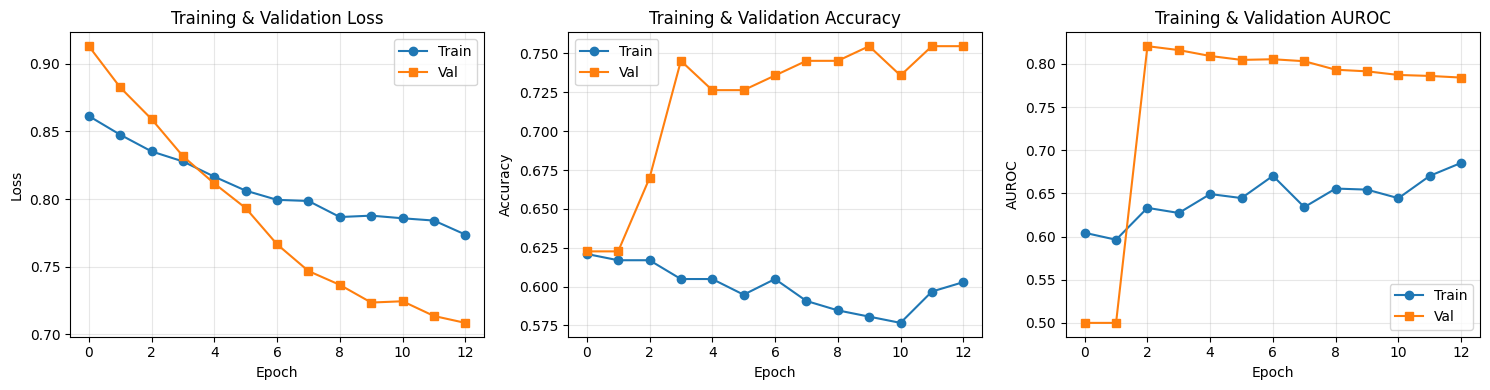

✅ Gráficos guardados: training_curves.png


In [15]:
# ============================================================================
# VISUALIZACIÓN
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'], label='Val', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUROC
axes[2].plot(history['train_auc'], label='Train', marker='o')
axes[2].plot(history['val_auc'], label='Val', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUROC')
axes[2].set_title('Training & Validation AUROC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráficos guardados: training_curves.png")

In [16]:
# ============================================================================
# VERIFICACIÓN:
# ============================================================================

print("="*70)
print("🔍 ANÁLISIS DETALLADO DEL MEJOR MODELO")
print("="*70)

# Cargar mejor modelo
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

# Evaluar en VAL (para entender el 0.988)
val_loss, val_acc, val_auc, val_preds, val_labels = eval_epoch(model, val_loader, criterion)

print(f"\n📊 VALIDACIÓN:")
print(f"   AUROC: {val_auc:.3f}")
print(f"   Accuracy: {val_acc:.3f}")

# Análisis de predicciones
val_preds_array = np.array(val_preds)
val_labels_array = np.array(val_labels)

print(f"\n🔍 Distribución de predicciones:")
print(f"   Min pred: {val_preds_array.min():.3f}")
print(f"   Max pred: {val_preds_array.max():.3f}")
print(f"   Mean pred: {val_preds_array.mean():.3f}")
print(f"   Std pred: {val_preds_array.std():.3f}")

# ¿Hay variedad?
preds_binary = (val_preds_array > 0.5).astype(int)
unique, counts = np.unique(preds_binary, return_counts=True)
print(f"\n   Predicciones binarias:")
for u, c in zip(unique, counts):
    print(f"      Clase {u}: {c} ({c/len(preds_binary)*100:.1f}%)")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(val_labels_array, preds_binary)
print(f"\n   Confusion Matrix:")
print(f"                 Pred")
print(f"               0     1")
print(f"   True 0   {cm[0,0]:>4}  {cm[0,1]:>4}")
print(f"        1   {cm[1,0]:>4}  {cm[1,1]:>4}")

# Precision, Recall, F1
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, _ = precision_recall_fscore_support(
    val_labels_array, preds_binary, average='binary', zero_division=0
)
print(f"\n   Precision: {prec:.3f}")
print(f"   Recall:    {rec:.3f}")
print(f"   F1:        {f1:.3f}")

# ¿Es el AUC real?
print(f"\n🎯 Interpretación:")
if val_auc > 0.95 and cm[1,1] > 0 and cm[0,0] > 0:
    print("   ✅ Modelo parece funcionar bien")
    print("   ⚠️  Pero val set es pequeño (alta varianza)")
elif cm[1,1] == 0 or cm[0,0] == 0:
    print("   ❌ Modelo predice solo una clase")
    print("   AUC alto es espurio")
else:
    print("   ⚠️  Resultado ambiguo")

🔍 ANÁLISIS DETALLADO DEL MEJOR MODELO



📊 VALIDACIÓN:
   AUROC: 0.820
   Accuracy: 0.670

🔍 Distribución de predicciones:
   Min pred: 0.180
   Max pred: 0.508
   Mean pred: 0.465
   Std pred: 0.049

   Predicciones binarias:
      Clase 0: 83 (78.3%)
      Clase 1: 23 (21.7%)

   Confusion Matrix:
                 Pred
               0     1
   True 0     57     9
        1     26    14

   Precision: 0.609
   Recall:    0.350
   F1:        0.444

🎯 Interpretación:
   ⚠️  Resultado ambiguo
